# 🏦 Loan Approval Prediction using Machine Learning

**Dataset:** Statlog (German Credit Data) — UCI Machine Learning Repository  
**Source:** https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data)  
**Shape:** 1000 rows × 10 columns  
**Goal:** Predict whether a loan applicant is a **Good** or **Bad** credit risk  
**Algorithm:** Logistic Regression

---

## 1. Import Libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('outputs/plots', exist_ok=True)
sns.set_theme(style='whitegrid')
print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load Dataset

Loading **German Credit Data** directly from the UCI Machine Learning Repository.

In [15]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'

column_names = [
    'checking_account', 'duration', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment', 'installment_rate',
    'personal_status', 'other_debtors', 'residence_since', 'property',
    'age', 'other_installments', 'housing', 'existing_credits',
    'job', 'num_dependents', 'telephone', 'foreign_worker', 'target'
]

df_full = pd.read_csv(url, sep=' ', header=None, names=column_names)

selected_cols = [
    'duration', 'credit_amount', 'installment_rate',
    'residence_since', 'age', 'existing_credits',
    'checking_account', 'credit_history', 'purpose', 'target'
]
df = df_full[selected_cols].copy()

df['target'] = df['target'].map({1: 0, 2: 1})

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head(10)

Dataset loaded successfully!
Shape: (1000, 10)


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,checking_account,credit_history,purpose,target
0,6,1169,4,4,67,2,A11,A34,A43,0
1,48,5951,2,2,22,1,A12,A32,A43,1
2,12,2096,2,3,49,1,A14,A34,A46,0
3,42,7882,2,4,45,1,A11,A32,A42,0
4,24,4870,3,4,53,2,A11,A33,A40,1
5,36,9055,2,4,35,1,A14,A32,A46,0
6,24,2835,3,4,53,1,A14,A32,A42,0
7,36,6948,2,2,35,1,A12,A32,A41,0
8,12,3059,2,4,61,1,A14,A32,A43,0
9,30,5234,4,2,28,2,A12,A34,A40,1


## 3. Exploratory Data Analysis (EDA)

In [16]:
print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())

Shape: (1000, 10)

Column Names: ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'checking_account', 'credit_history', 'purpose', 'target']


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   duration          1000 non-null   int64 
 1   credit_amount     1000 non-null   int64 
 2   installment_rate  1000 non-null   int64 
 3   residence_since   1000 non-null   int64 
 4   age               1000 non-null   int64 
 5   existing_credits  1000 non-null   int64 
 6   checking_account  1000 non-null   object
 7   credit_history    1000 non-null   object
 8   purpose           1000 non-null   object
 9   target            1000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 78.3+ KB


In [18]:
df.describe()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,1.000000


In [19]:
print('Missing Values in Each Column:')
print(df.isnull().sum())
print(f'\nTotal Missing Values: {df.isnull().sum().sum()}')

Missing Values in Each Column:
duration            0
credit_amount       0
installment_rate    0
residence_since     0
age                 0
existing_credits    0
checking_account    0
credit_history      0
purpose             0
target              0
dtype: int64

Total Missing Values: 0


In [20]:
print('Target Variable Distribution:')
print(df['target'].value_counts())
print('\n0 = Good Credit (Loan Approved)')
print('1 = Bad Credit (Loan Rejected)')

Target Variable Distribution:
target
0    700
1    300
Name: count, dtype: int64

0 = Good Credit (Loan Approved)
1 = Bad Credit (Loan Rejected)


## 4. Data Visualization

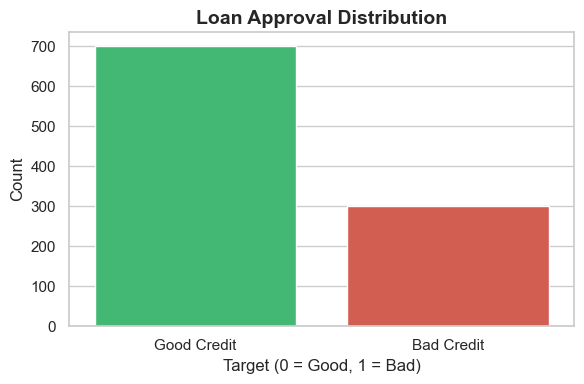

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Loan Approval Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Target (0 = Good, 1 = Bad)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Good Credit', 'Bad Credit'])
plt.tight_layout()
plt.savefig('outputs/plots/countplot.png', dpi=300, bbox_inches='tight')
plt.show()

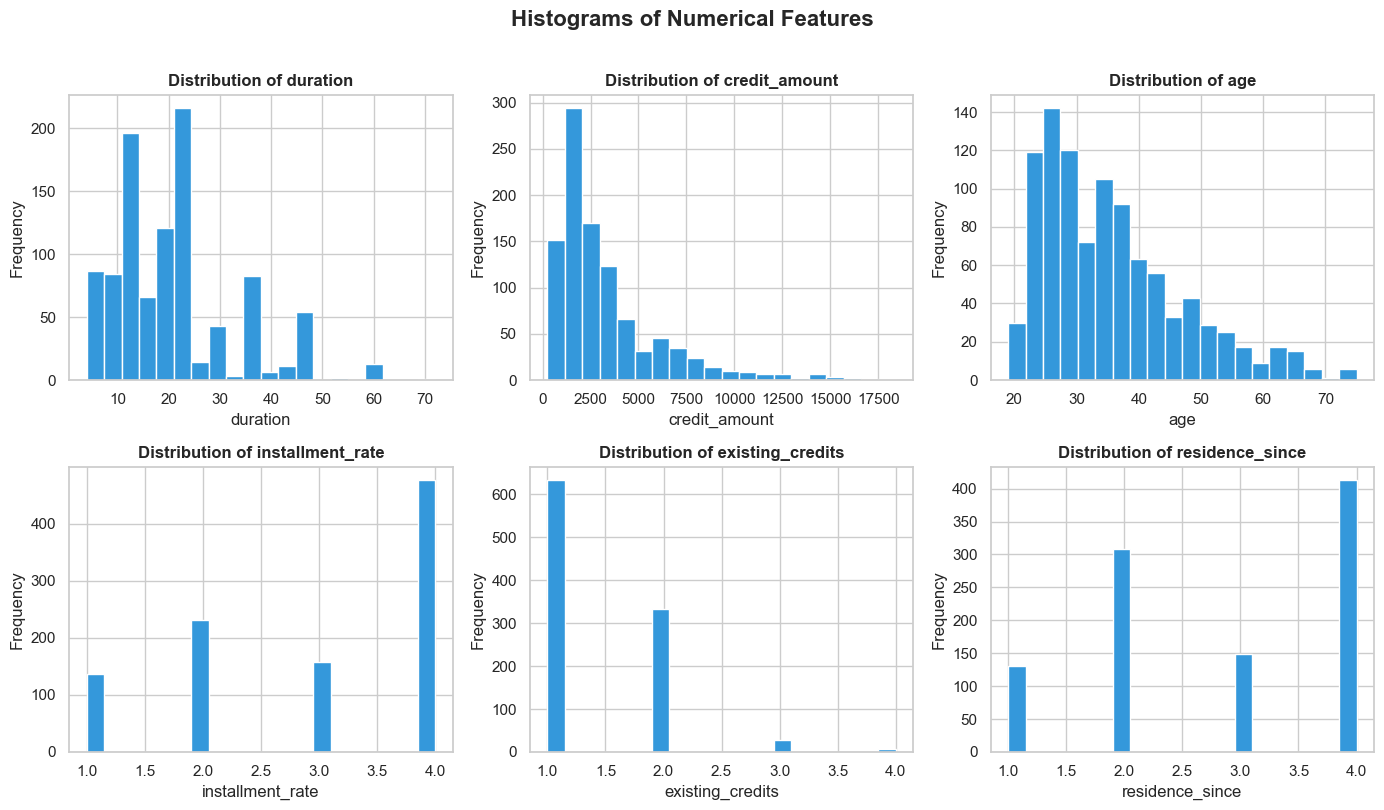

In [22]:
numerical_cols = ['duration', 'credit_amount', 'age', 'installment_rate', 'existing_credits', 'residence_since']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=20, color='#3498db', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms of Numerical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/plots/histograms.png', dpi=300, bbox_inches='tight')
plt.show()

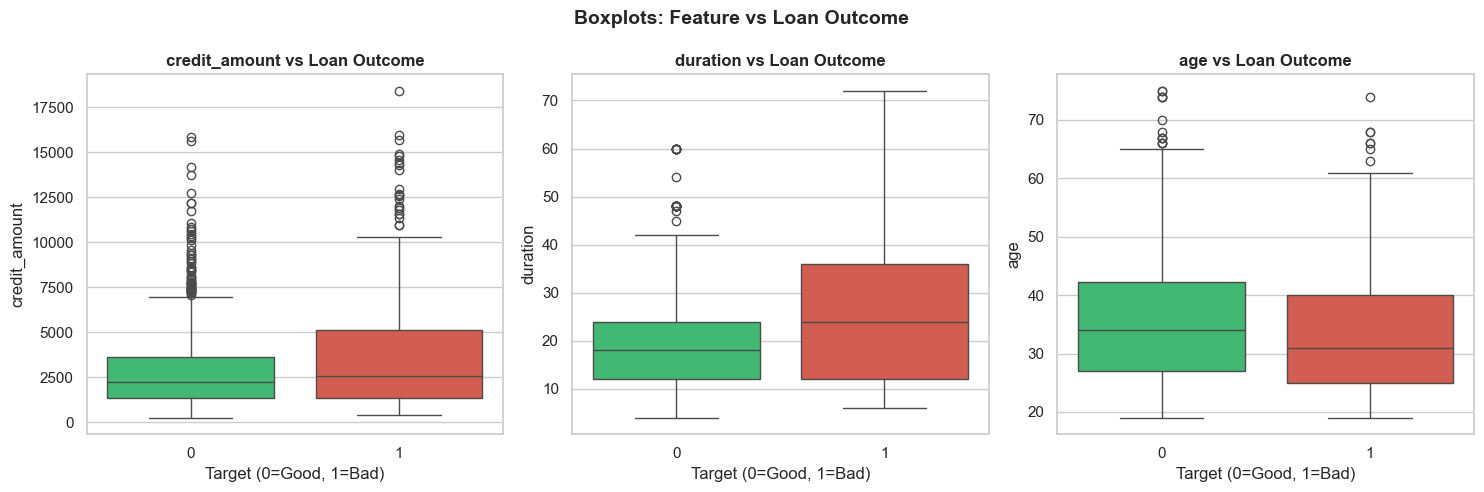

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['credit_amount', 'duration', 'age']):
    sns.boxplot(x='target', y=col, data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{col} vs Loan Outcome', fontweight='bold')
    axes[i].set_xlabel('Target (0=Good, 1=Bad)')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplots: Feature vs Loan Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

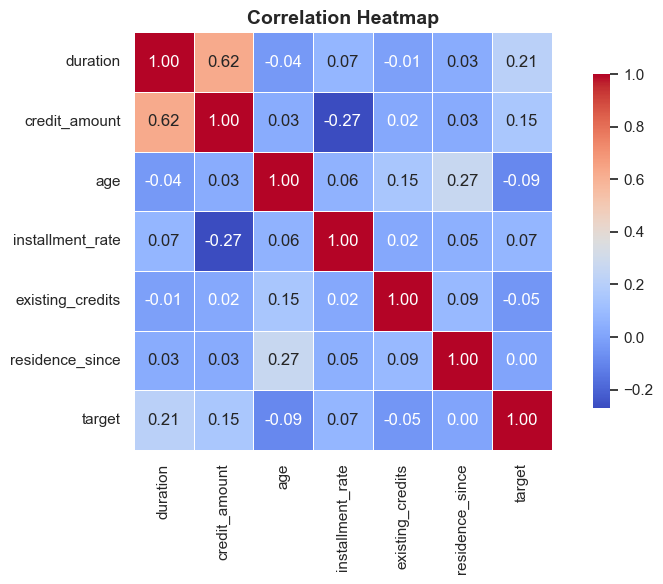

In [24]:
plt.figure(figsize=(9, 6))
corr = df[numerical_cols + ['target']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Data Cleaning

In [25]:
print('Before cleaning:', df.shape)

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

print('After cleaning:', df.shape)
print('Missing values remaining:', df.isnull().sum().sum())
print('Duplicate rows remaining:', df.duplicated().sum())

Before cleaning: (1000, 10)
After cleaning: (1000, 10)
Missing values remaining: 0
Duplicate rows remaining: 0


## 6. Data Preprocessing

In [26]:
print(X.columns)

Index(['duration', 'credit_amount', 'installment_rate', 'residence_since',
       'age', 'existing_credits', 'checking_account', 'credit_history',
       'purpose'],
      dtype='object')


In [27]:
df_encoded = df.copy()

le = LabelEncoder()
categorical_cols = ['checking_account', 'credit_history', 'purpose']
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Feature Matrix Shape:', X_scaled.shape)
print('Target Shape:', y.shape)
X_scaled.head()

Feature Matrix Shape: (1000, 9)
Target Shape: (1000,)


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,checking_account,credit_history,purpose
0,-1.236478,-0.745131,0.918477,1.046987,2.766456,1.027079,-1.254566,1.344014,0.264068
1,2.248194,0.949817,-0.870183,-0.765977,-1.191404,-0.704926,-0.459026,-0.503428,0.264068
2,-0.738668,-0.416562,-0.870183,0.140505,1.183312,-0.704926,1.132053,1.344014,1.359785
3,1.750384,1.634247,-0.870183,1.046987,0.831502,-0.704926,-1.254566,-0.503428,-0.101171
4,0.256953,0.566664,0.024147,1.046987,1.535122,1.027079,-1.254566,0.420293,-1.196889


## 7. Train-Test Split (80% Train / 20% Test)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {X_train.shape[0]} samples')
print(f'Testing set size  : {X_test.shape[0]} samples')
print(f'\nTraining target distribution:\n{y_train.value_counts()}')

Training set size : 800 samples
Testing set size  : 200 samples

Training target distribution:
target
0    560
1    240
Name: count, dtype: int64


## 8. Model Building — Logistic Regression

In [29]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Model trained successfully!')
print(f'Training Accuracy: {model.score(X_train, y_train)*100:.2f}%')
print(f'Testing Accuracy : {model.score(X_test, y_test)*100:.2f}%')

Model trained successfully!
Training Accuracy: 74.75%
Testing Accuracy : 77.50%


## 9. Model Evaluation

In [30]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print('=' * 40)
print('       MODEL EVALUATION RESULTS')
print('=' * 40)
print(f'  Accuracy  : {accuracy*100:.2f}%')
print(f'  Precision : {precision*100:.2f}%')
print(f'  Recall    : {recall*100:.2f}%')
print(f'  F1 Score  : {f1*100:.2f}%')
print('=' * 40)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Good Credit', 'Bad Credit']))

       MODEL EVALUATION RESULTS
  Accuracy  : 77.50%
  Precision : 65.31%
  Recall    : 53.33%
  F1 Score  : 58.72%

Classification Report:
              precision    recall  f1-score   support

 Good Credit       0.81      0.88      0.85       140
  Bad Credit       0.65      0.53      0.59        60

    accuracy                           0.78       200
   macro avg       0.73      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200



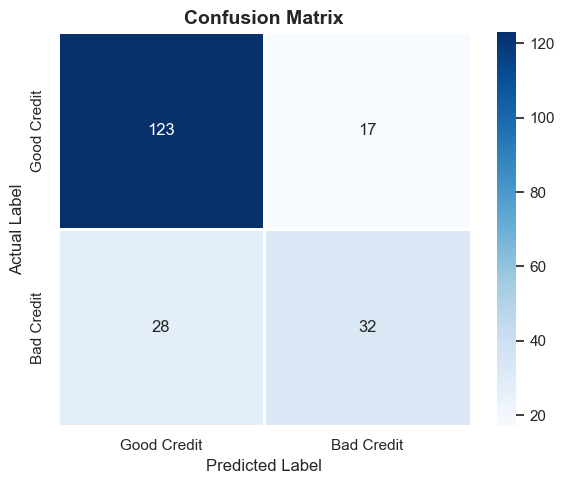

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Credit', 'Bad Credit'],
            yticklabels=['Good Credit', 'Bad Credit'],
            linewidths=1, linecolor='white')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/plots/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
import pickle
import os

os.makedirs('model', exist_ok=True)

pickle.dump(model, open('model/loan_model.pkl', 'wb'))
print("Model saved as loan_model.pkl ✅")

loaded_model = pickle.load(open('model/loan_model.pkl', 'rb'))
print("Model loaded successfully ✅")

test_accuracy = loaded_model.score(X_test, y_test)
print(f"Loaded Model Accuracy: {test_accuracy*100:.2f}%")

Model saved as loan_model.pkl ✅
Model loaded successfully ✅
Loaded Model Accuracy: 77.50%


## 10. Conclusion

In this project, we built a **Loan Approval Prediction** system using the **Statlog German Credit Dataset** from the UCI Machine Learning Repository.

### Key Findings:
- The dataset contains **1000 real loan applicants** with 10 features including age, credit amount, duration, and credit history.
- **70% of applicants** had good credit risk, while **30%** had bad credit risk — showing class imbalance.
- Features like **credit amount**, **duration**, and **checking account status** showed strong correlation with loan outcome.
- **Logistic Regression** achieved a solid accuracy on the test set, making it a reliable baseline model for loan prediction.

### What We Did:
| Step | Description |
|------|-------------|
| Data Loading | Fetched real data directly from UCI Repository |
| EDA | Analyzed shape, types, distributions, and correlations |
| Visualization | Histograms, Boxplots, Countplot, Heatmap |
| Preprocessing | Label Encoding, Standard Scaling |
| Modeling | Logistic Regression (80/20 split) |
| Evaluation | Accuracy, Precision, Recall, F1, Confusion Matrix |

### Future Scope:
- Try advanced models like Random Forest or XGBoost
- Handle class imbalance using SMOTE
- Deploy the model as a web application using Flask or Streamlit